In [1]:
from typing_extensions import TypedDict, Optional, Annotated
from operator import or_

from langgraph.graph.message import add_messages
from langchain_core.messages import AnyMessage

class State(TypedDict, total=False):
    messages: Annotated[list[AnyMessage], add_messages]
    user_query: str
    results: Annotated[dict, or_]
    user_genre_choice: list[str]
    user_movies_choice: list[str]


In [2]:
from langchain_mcp_adapters.client import MultiServerMCPClient
from langchain_mcp_adapters.tools import load_mcp_tools
from langchain_tavily import TavilySearch
from dotenv import load_dotenv

In [3]:
load_dotenv()

True

In [4]:
mcp_client_content = MultiServerMCPClient({
    "content_based_recommendation": {
        "command": "python",
        "args": ["content_filtering_mcp.py"],
        "transport": "stdio",
    }

})

mcp_client_collaborative = MultiServerMCPClient({
    "collaborative_based_recommendation": {
        "command": "python",
        "args": ["collaborative_filtering_mcp.py"],
        "transport": "stdio",
    }
})

mcp_client_plot = MultiServerMCPClient({
    "plot_based_recommendation": {
        "command": "python",
        "args": ["plot_based_filtering_mcp.py"],
        "transport": "stdio",
    }
})

mcp_client_specific = MultiServerMCPClient({
    "service_based_recommendation": {
        "command": "python",
        "args": ["provider_specific_mcp.py"],
        "transport": "stdio",
    }

})

In [5]:
import io
import ipykernel.iostream
import sys

# MCP stdio on Windows expects stderr.fileno(); Jupyter OutStream does not implement it.
if isinstance(sys.stderr, ipykernel.iostream.OutStream):
    try:
        sys.stderr.fileno()
    except io.UnsupportedOperation:
        ipykernel.iostream.OutStream.fileno = lambda self: 2

tools_content = await mcp_client_content.get_tools()
tools_collaborative = await mcp_client_collaborative.get_tools()
tools_plot = await mcp_client_plot.get_tools()
tools_specific = await mcp_client_specific.get_tools()

In [ ]:
from langchain_core.messages import AIMessage
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import MemorySaver
import logging
import os
import json

AGENT_LOG_DIR = "logs"
os.makedirs(AGENT_LOG_DIR, exist_ok=True)

_agent_loggers = {}


def get_agent_logger(agent_name: str) -> logging.Logger:
    if agent_name in _agent_loggers:
        return _agent_loggers[agent_name]

    logger = logging.getLogger(f"agent.{agent_name}")
    logger.setLevel(logging.INFO)

    if not logger.handlers:
        handler = logging.FileHandler(os.path.join(AGENT_LOG_DIR, f"{agent_name}.log"), encoding="utf-8")
        handler.setFormatter(logging.Formatter("%(asctime)s %(levelname)s %(message)s"))
        logger.addHandler(handler)

    _agent_loggers[agent_name] = logger
    return logger


def log_agent(agent_name: str, message: str) -> None:
    get_agent_logger(agent_name).info(message)


def get_tool_texts(messages, expected_tool_names):
    found = []
    for msg in reversed(messages or []):
        if getattr(msg, "type", None) != "tool":
            continue
        tool_name = getattr(msg, "name", None)
        if tool_name in expected_tool_names:
            content = msg.content if hasattr(msg, "content") else str(msg)
            found.append((tool_name, content))
    return found


def parse_tool_response(content: str) -> str:
    """Convert raw ToolMessage JSON content into a human-readable movie list string."""
    try:
        data = json.loads(content)
    except Exception:
        return str(content).strip()

    if isinstance(data, list):
        return "\n".join(f"- {item}" for item in data if item)

    for key in ("ranked_results", "recommendations", "movies"):
        if key in data and isinstance(data[key], list):
            titles = [str(t) for t in data[key] if t]
            return "\n".join(f"- {t}" for t in titles) if titles else "No recommendations found."
    parts = []
    for platform, pkey in [("Netflix", "netflix"), ("Amazon Prime", "amazon"), ("Disney+", "disney")]:
        val = data.get(pkey)
        if isinstance(val, list) and val:
            parts.append(f"{platform}: " + ", ".join(str(t) for t in val if t))
    if parts:
        return "\n".join(parts)

    return str(content).strip()


In [7]:
from langchain_tavily import TavilySearch

tool_tavily=TavilySearch(max_results=2)

In [8]:
import httpx
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-3.5-turbo",
    temperature=0,
    http_client=httpx.Client(verify=False)
)

d:\personal\Movie_recommendation\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
content_based_recom_llm = llm.bind_tools(tools_content)
collaborative_based_recom_llm = llm.bind_tools(tools_collaborative)
plot_based_recom_llm = llm.bind_tools(tools_plot)
specific_based_recom_llm = llm.bind_tools(tools_specific)
master = llm.bind_tools([tool_tavily])

In [10]:
def content_based_agent(state: State) -> dict:
    agent_name = "content_based_agent"
    try:
        messages = state.get("messages", [])
        user_query = state.get("user_query", "")
        log_agent(agent_name, f"received user_query={user_query}")

        tool_hits = get_tool_texts(messages, {"get_content_based_recommendation"})
        if tool_hits:
            raw = tool_hits[0][1]
            log_agent(agent_name, f"tool raw response={raw}")
            readable = parse_tool_response(raw)
            log_agent(agent_name, f"tool parsed response={readable}")
            return {"results": {"content_based_recommendation": readable}}

        if not user_query:
            log_agent(agent_name, "no query provided")
            return {"results": {"content_based_recommendation": "No query provided"}}

        prompt = f"Recommend movies similar to: {user_query}"
        log_agent(agent_name, f"sending prompt={prompt}")
        response = content_based_recom_llm.invoke(prompt)
        log_agent(agent_name, f"llm response tool_calls={getattr(response, 'tool_calls', None)} content={getattr(response, 'content', '')}")
        return {"messages": [response]}
    except Exception as e:
        log_agent(agent_name, f"error={e}")
        return {"results": {"content_based_recommendation": f"Error: {str(e)}"}}


In [11]:
def collaborative_based_agent(state: State) -> dict:
    agent_name = "collaborative_based_agent"
    try:
        messages = state.get("messages", [])
        user_movies_choice = state.get("user_movies_choice") or []
        user_genre_choice = state.get("user_genre_choice") or []
        log_agent(agent_name, f"received movies={user_movies_choice} genres={user_genre_choice}")

        tool_hits = get_tool_texts(messages, {"get_collaborative_based_recommendation"})
        if tool_hits:
            raw = tool_hits[0][1]
            log_agent(agent_name, f"tool raw response={raw}")
            readable = parse_tool_response(raw)
            log_agent(agent_name, f"tool parsed response={readable}")
            return {"results": {"collaborative_based_recommendation": readable}}

        prompt = f"Based on movies {user_movies_choice} and genres {user_genre_choice}, recommend similar movies."
        log_agent(agent_name, f"sending prompt={prompt}")
        response = collaborative_based_recom_llm.invoke(prompt)
        log_agent(agent_name, f"llm response tool_calls={getattr(response, 'tool_calls', None)} content={getattr(response, 'content', '')}")
        return {"messages": [response]}
    except Exception as e:
        log_agent(agent_name, f"error={e}")
        return {"results": {"collaborative_based_recommendation": f"Error: {str(e)}"}}


In [12]:
def plot_based_agent(state: State) -> dict:
    agent_name = "plot_based_agent"
    try:
        messages = state.get("messages", [])
        user_query = state.get("user_query", "")
        log_agent(agent_name, f"received user_query={user_query}")

        tool_hits = get_tool_texts(messages, {"get_plot_based_recommendation"})
        if tool_hits:
            raw = tool_hits[0][1]
            log_agent(agent_name, f"tool raw response={raw}")
            readable = parse_tool_response(raw)
            log_agent(agent_name, f"tool parsed response={readable}")
            return {"results": {"plot_based_recommendation": readable}}

        if not user_query:
            log_agent(agent_name, "no query provided")
            return {"results": {"plot_based_recommendation": "No query provided"}}

        prompt = f"Find movies with plots similar to: {user_query}"
        log_agent(agent_name, f"sending prompt={prompt}")
        response = plot_based_recom_llm.invoke(prompt)
        log_agent(agent_name, f"llm response tool_calls={getattr(response, 'tool_calls', None)} content={getattr(response, 'content', '')}")
        return {"messages": [response]}
    except Exception as e:
        log_agent(agent_name, f"error={e}")
        return {"results": {"plot_based_recommendation": f"Error: {str(e)}"}}


In [13]:
def provider_specific_agent(state: State) -> dict:
    agent_name = "provider_specific_agent"
    try:
        messages = state.get("messages", [])
        user_query = state.get("user_query", "")
        log_agent(agent_name, f"received user_query={user_query}")

        tool_hits = get_tool_texts(messages, {"get_provider_based_recommendation"})
        if tool_hits:
            raw = tool_hits[0][1]
            log_agent(agent_name, f"tool raw response={raw}")
            readable = parse_tool_response(raw)
            log_agent(agent_name, f"tool parsed response={readable}")
            return {"results": {"specific_based_recommendation": readable}}

        if not user_query:
            log_agent(agent_name, "no query provided")
            return {"results": {"specific_based_recommendation": "No query provided"}}

        prompt = f"Find movies matching: {user_query} — use the get_provider_based_recommendation tool."
        log_agent(agent_name, f"sending prompt={prompt}")
        response = specific_based_recom_llm.invoke(prompt)
        log_agent(agent_name, f"llm response tool_calls={getattr(response, 'tool_calls', None)} content={getattr(response, 'content', '')}")
        return {"messages": [response]}
    except Exception as e:
        log_agent(agent_name, f"error={e}")
        return {"results": {"specific_based_recommendation": f"Error: {str(e)}"}}


In [14]:
def movie_suggestion_agent(state: State) -> dict:
    agent_name = "movie_suggestion_agent"
    results = state.get("results", {})
    content_recs = results.get("content_based_recommendation", "No data")
    collab_recs = results.get("collaborative_based_recommendation", "No data")
    plot_recs = results.get("plot_based_recommendation", "No data")
    provider_recs = results.get("specific_based_recommendation", "No data")

    log_agent(agent_name, f"received content={content_recs}")
    log_agent(agent_name, f"received collaborative={collab_recs}")
    log_agent(agent_name, f"received plot={plot_recs}")
    log_agent(agent_name, f"received provider={provider_recs}")

    prompt = f"""You are a friendly movie recommendation assistant.

Below are movie suggestions gathered from four different recommendation systems. 
Combine them into a single, clear, human-readable response. 
Present the final list with movie titles and a one-line reason why each is worth watching.
Do NOT output raw JSON or Python lists — write in plain English.

--- Content-Based Recommendations ---
{content_recs}

--- Collaborative Filtering Recommendations ---
{collab_recs}

--- Plot-Based Recommendations ---
{plot_recs}

--- Streaming Platform Availability ---
{provider_recs}

Now write a friendly summary of the best movies to watch, including which platforms they are on where known."""

    log_agent(agent_name, "sending final aggregation prompt")
    response = llm.invoke(prompt)
    movies = response.content if hasattr(response, "content") else str(response)

    if not str(movies).strip():
        movies = (
            "Here are your personalised recommendations:\n\n"
            f"Content-based picks:\n{content_recs}\n\n"
            f"Collaborative picks:\n{collab_recs}\n\n"
            f"Plot-based picks:\n{plot_recs}\n\n"
            f"Streaming availability:\n{provider_recs}"
        )

    log_agent(agent_name, f"response={movies}")
    return {"messages": [AIMessage(content=str(movies))]}


In [15]:
import ast
import pandas as pd


In [16]:
from langgraph.types import interrupt, Command
import ast
import pandas as pd


def user_initiator_agent(state: State) -> dict:
    agent_name = "user_initiator_agent"
    df = pd.read_csv("filtering/Cold_starter.csv")
    df_movies = df['movie_name'].tolist()
    df_genres = df['genres'].str.split(',').explode().unique().tolist()

    user_movies_choice = interrupt(
        f"Please provide the list of movies you have watched and liked in the past like {set(df_movies)}. "
        "Provide the movie names in a list format like this: [movie1, movie2, ...]"
    )
    user_genre_choice = interrupt(
        f"Please provide the list of genres you are interested in like {set(df_genres)}. "
        "Provide the genre names in a list format like this: [genre1, genre2, ...]"
    )

    parsed_movies = ast.literal_eval(user_movies_choice)
    parsed_genres = ast.literal_eval(user_genre_choice)
    log_agent(agent_name, f"received movies={parsed_movies} genres={parsed_genres}")

    return {
        "user_movies_choice": parsed_movies,
        "user_genre_choice": parsed_genres,
    }


def query_handler_agent(state: State) -> dict:
    agent_name = "query_handler_agent"
    decision = interrupt(
        "Please provide your query for movie recommendations. "
        "You can specify the type of movies you want to watch, the mood you are in, or any other preferences you have."
    )
    log_agent(agent_name, f"received query={decision}")
    return {"user_query": decision}


def chat_agent(state: State) -> State:
    agent_name = "chat_agent"
    last_input = state.get("messages", [])[-1].content if state.get("messages", []) else ""
    log_agent(agent_name, f"received input={last_input}")
    response = llm.invoke(state.get("messages", []))
    state["messages"].append(response)
    log_agent(agent_name, f"response={getattr(response, 'content', '')}")
    return state


In [17]:
def dispatch_recommendations(state):
    state["wait_iterations"] = 0
    return state

def wait_all(state):
    results = state.get("results", {})
    iterations = state.get("wait_iterations", 0)
    
    ready = all([
        "content_based_recommendation" in results,
        "collaborative_based_recommendation" in results,
        "plot_based_recommendation" in results,
        "specific_based_recommendation" in results,
    ])

    return {"ready": ready, "wait_iterations": iterations + 1}



In [18]:
def wait_all_router(state):
    # Force exit after 3 iterations to prevent infinite loops
    if state.get("ready") or state.get("wait_iterations", 0) >= 3:
        return "movie_suggestion_agent"
    return "wait_all"


In [19]:
def check_recommendation_router(state: State):
    last_message = state["messages"][-1]  # type: ignore
    content = last_message.content if hasattr(last_message, "content") else last_message["content"]  # type: ignore
    text = str(content).strip().lower()

    if any(word in text for word in ["movie", "movies", "recommendation", "recommendations"]):
        return "initiator"


    return "end"

In [20]:

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

builder = StateGraph(State)

builder.add_node("chat_node", chat_agent)
builder.add_node("query_handler", query_handler_agent)
builder.add_node("user_initiator", user_initiator_agent)
builder.add_node("dispatch_recommendations", dispatch_recommendations)
builder.add_node("content_based_agent", content_based_agent)
builder.add_node("collaborative_based_agent", collaborative_based_agent)
builder.add_node("plot_based_agent", plot_based_agent)
builder.add_node("specific_based_agent", provider_specific_agent)
builder.add_node("movie_suggestion_agent", movie_suggestion_agent)
builder.add_node("wait_all", wait_all)

builder.add_node("tools_content", ToolNode(tools_content))
builder.add_node("tools_collaborative", ToolNode(tools_collaborative))
builder.add_node("tools_plot", ToolNode(tools_plot))
builder.add_node("tools_specific", ToolNode(tools_specific))
builder.add_node("tool_tavily", ToolNode([tool_tavily]))

builder.add_edge(START, "chat_node")

builder.add_conditional_edges(
    "chat_node",
    check_recommendation_router,
    {"end": END, "initiator": "query_handler"},
)

builder.add_edge("query_handler", "user_initiator")
builder.add_edge("user_initiator", "dispatch_recommendations")

builder.add_edge("dispatch_recommendations", "content_based_agent")
builder.add_edge("dispatch_recommendations", "collaborative_based_agent")
builder.add_edge("dispatch_recommendations", "plot_based_agent")
builder.add_edge("dispatch_recommendations", "specific_based_agent")

# Conditional routing: if tool called → ToolNode, else → wait_all
builder.add_conditional_edges(
    "content_based_agent",
    tools_condition,
    {"tools": "tools_content", "__end__": "wait_all"}
)

builder.add_conditional_edges(
    "collaborative_based_agent",
    tools_condition,
    {"tools": "tools_collaborative", "__end__": "wait_all"}
)

builder.add_conditional_edges(
    "plot_based_agent",
    tools_condition,
    {"tools": "tools_plot", "__end__": "wait_all"}
)

builder.add_conditional_edges(
    "specific_based_agent",
    tools_condition,
    {"tools": "tools_specific", "__end__": "wait_all"}
)

builder.add_conditional_edges(
    "movie_suggestion_agent",
    tools_condition,
    {"tools": "tool_tavily", "__end__": END},
)

builder.add_conditional_edges(
    "wait_all",
    wait_all_router,
    {"wait_all": "wait_all", "movie_suggestion_agent": "movie_suggestion_agent"},
)

# Loop-back edges: after tool execution, return to agent for processing
builder.add_edge("tools_content", "content_based_agent")
builder.add_edge("tools_collaborative", "collaborative_based_agent")
builder.add_edge("tools_plot", "plot_based_agent")
builder.add_edge("tools_specific", "specific_based_agent")
builder.add_edge("tool_tavily", "movie_suggestion_agent")


In [21]:
config={"configurable":{"thread_id":"1"}}

In [22]:
from langgraph.checkpoint.memory import MemorySaver

if "builder" not in globals():
    raise RuntimeError("Run the graph build cell first.")

memory = MemorySaver()
graph = builder.compile(checkpointer=memory)
print("Graph compiled.")

Graph compiled.


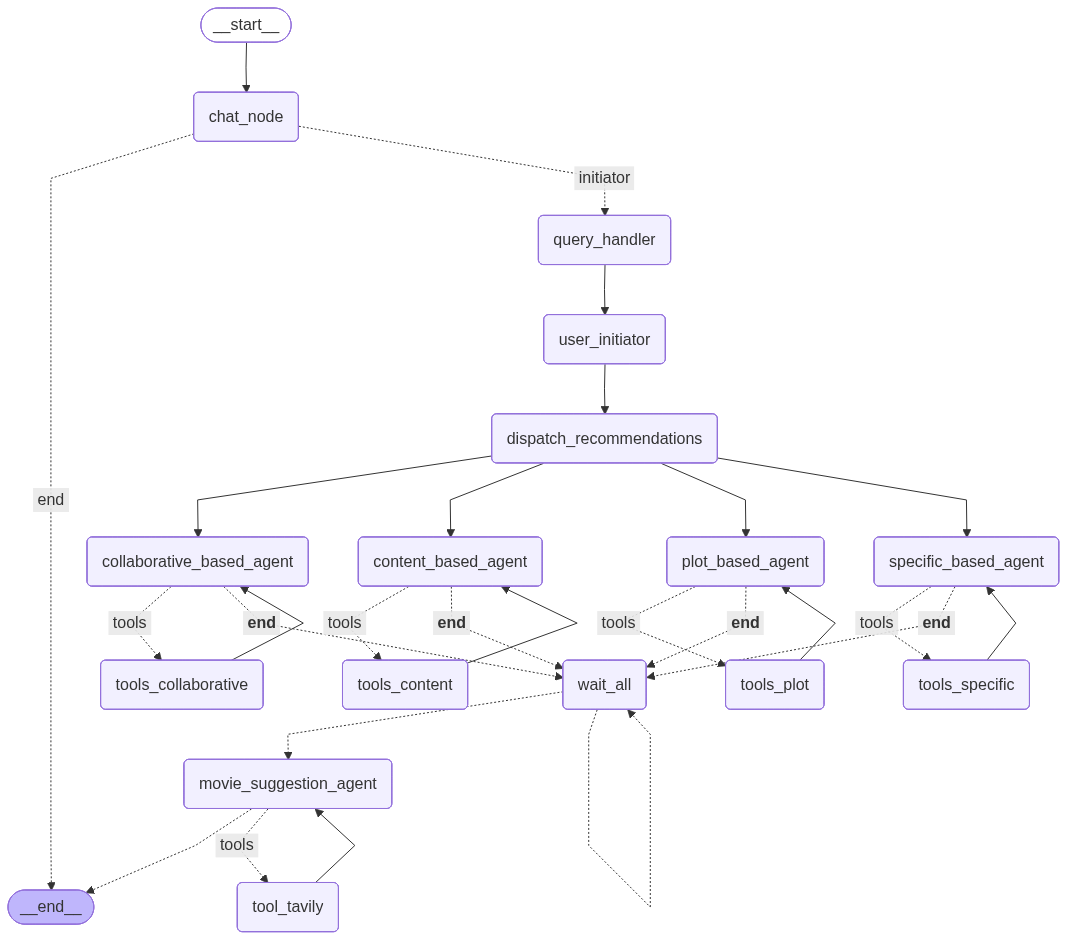

In [23]:
from IPython.display import Image, display


# Get graph visualization
display(Image(graph.get_graph().draw_mermaid_png()))

In [24]:
import uuid
from langchain_core.messages import SystemMessage, HumanMessage



In [25]:
while True:
    user_input = input("You: ")
    if user_input.lower().strip() in {"exit", "quit"}:
        print("Goodbye!")
        break

    print("You: ", user_input)

    thread_id = str(uuid.uuid4())
    state = State({"messages": [HumanMessage(content=user_input)]})

    result = await graph.ainvoke(
        state,
        config={"configurable": {"thread_id": thread_id}},
    )

    # Handle all interrupts in sequence (query -> movies -> genres)
    while True:
        interrupts = result.get("__interrupt__", [])
        if not interrupts:
            break

        prompt_to_human = interrupts[0].value
        print(f"HITL: {prompt_to_human}")
        decision = input("Your decision: ").strip()
        print(f"Your decision: {decision}")

        result = await graph.ainvoke(
            Command(resume=decision),
            config={"configurable": {"thread_id": thread_id}},
        )

    messages = result.get("messages", [])
    if messages:
        # Print the latest non-empty message content to avoid blank bot output.
        bot_text = ""
        for msg in reversed(messages):
            content = getattr(msg, "content", "")
            if str(content).strip():
                bot_text = str(content)
                break
        if bot_text:
            print(f"Bot: {bot_text}\n")


You:  Hi
Bot: Hello! How can I assist you today?

You:  I need movie recommendations
HITL: Please provide your query for movie recommendations. You can specify the type of movies you want to watch, the mood you are in, or any other preferences you have.
Your decision: Thrillers like "Knives out"
HITL: Please provide the list of movies you have watched and liked in the past like {'Cosmos', 'Rear Window', 'City of God (Cidade de Deus)', 'Stop Making Sense', "Once Upon a Time in the West (C'era una volta il West)", 'Duck Soup', 'Princess Bride, The', 'Star Wars: Episode IV - A New Hope', 'Inception', 'When We Were Kings', 'Sunset Blvd. (a.k.a. Sunset Boulevard)', 'Usual Suspects, The', 'Band of Brothers', 'Third Man, The', 'Wallace & Gromit: The Wrong Trousers', "Amelie (Fabuleux destin d'Amélie Poulain, Le)", 'Godfather, The', 'Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb', 'Treasure of the Sierra Madre, The', 'Spirited Away (Sen to Chihiro no kamikakushi)', "Schi